In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [2]:
from src.utils.normalizer import Normalizer

In [454]:
device = "cuda:7"

weight_path = "./models/meta-llama/Llama-2-7b-hf/original_weights/layer_0/self_attn.q_proj.pt"
hessian_diag = weight_path.replace("original_weights", "hessianDiags/seed_0/pajama/128")


weight = torch.load(weight_path, map_location=device)["weight"].to(torch.float32).detach()
hessian_diag = torch.load(hessian_diag, map_location=device)["hessianDiag"].to(torch.float32    )

In [466]:
def N_M_loss(weight, N:int, M:int):
    """
    Computes the regularization loss to penalize the weight to get N:M sparsity.
    Args:
        weight (torch.Tensor): The weight tensor to be regularized.
        N (int): The numerator of the N:M sparsity ratio.
        M (int): The denominator of the N:M sparsity ratio.
    Returns:
        torch.Tensor: The computed regularization loss.
    """     
    
    weight_resized = weight.view(-1, M)
    # Get the smallest M-N elements along the last dimension
    smallest_elements = torch.sort(weight_resized.abs(), dim=-1).values[..., :M-N]
    # Compute the regularization loss as the sum of the smallest M-N elements
    loss = smallest_elements.abs().sum()
    return loss


def weighted_l2(weight, original_weight, hessian_diag):
    """
    Computes the regularization loss to penalize the weight to get N:M sparsity
    Args:
        weight (torch.Tensor): The weight tensor to be regularized.
        hessian_diag (torch.Tensor): The diagonal of the Hessian matrix.
        N (int): The numerator of the N:M sparsity ratio.
        M (int): The denominator of the N:M sparsity ratio.
        lambda_ (float): The regularization strength.
    Returns:
        torch.Tensor: The computed regularization loss.
    """
    
    return torch.sum((weight - original_weight) ** 2 * hessian_diag.unsqueeze(0))
    

In [467]:
class Sparse_Module(nn.Module):
    def __init__(self, original_pruned_weight:torch.FloatTensor, 
                 n_permutations:int,
                 N:int = 2,
                 M:int = 4):
        
        super(Sparse_Module, self).__init__()
        
        
        # self.permutations_0 = [torch.randperm(original_weight.shape[0]) for _ in range(n_permutations)]
        self.permutations_1 = [torch.arange(original_pruned_weight.shape[1])] + [torch.randperm(original_pruned_weight.shape[1]) for _ in range(n_permutations-1)]
        self.scaling_1 = nn.ParameterList([nn.Parameter(torch.ones(original_pruned_weight.shape[0]))] + [nn.Parameter(torch.zeros(original_pruned_weight.shape[0])) for _ in range(n_permutations-1)]).to(device)  
        self.weight = nn.Parameter(original_pruned_weight.clone().detach()) 
        
        self.N = N
        self.M = M
        
    def forward(self, weight=None):
        if weight is None:
            weight = self.weight
        # Apply permutations to the weight tensor
        reconstructed_weight = weight[:, self.permutations_1[0]] * self.scaling_1[0].unsqueeze(0)
        for i, perm_1 in enumerate(self.permutations_1[1:]):
            reconstructed_weight = reconstructed_weight + weight[:, perm_1] * self.scaling_1[i+1].unsqueeze(0)

        # reconstructed_weight = weight[self.permutations_0[0]]
        # for perm_0 in self.permutations_0[1:]:
        #     reconstructed_weight = reconstructed_weight + weight[perm_0]
            
        return reconstructed_weight
    
    def forward_pass_sparse(self):
        
        weight_use = self.weight.clone().view(-1, self.M)
        
        #zero out the smallest M-N elements along the last dimension
        smallest_idxs = torch.sort(torch.abs(weight_use), dim=-1).indices[..., :self.M-self.N]
        # print(smallest_idxs)
        mask = torch.ones_like(weight_use, dtype=torch.bool)
        mask.scatter_(1, smallest_idxs, False)
        # print(mask)
        sparse_weight = (weight_use * mask.float()).view_as(self.weight)
        # print(torch.sum(sparse_weight.view(-1, self.M) != 0,dim=-1))
        assert torch.all(torch.sum(sparse_weight.view(-1, self.M) != 0,dim=-1) <= self.N), "too many non-zero elements after masking."
        return self.forward(sparse_weight)
        
        
    
    def get_compression_ratio(self):
        """
        We compute the compression ratio as the ratio of remaining bits to the original bits.
        """
        n_original_bits = self.weight.numel() * 16  # 16 bits per float
        
        
        

In [468]:
class Sparse_Module2(nn.Module):
    def __init__(self, weight:torch.FloatTensor, 
                 n_permutations:int,
                 N:int = 2,
                 M:int = 4):
        
        super(Sparse_Module2, self).__init__()
        
        
        # self.permutations_0 = [torch.randperm(original_weight.shape[0]) for _ in range(n_permutations)]
        self.permutations_1 = [torch.randperm(weight.shape[1]) for _ in range(n_permutations)]
        self.scaling_1 = nn.ParameterList([nn.Parameter(torch.randn(weight.shape[0])) for _ in range(n_permutations)]).to(device)  
        self.weight = nn.Parameter(torch.randn_like(weight).clone().detach() * torch.std(weight))
        
        self.N = N
        self.M = M
        
    def forward(self, weight=None):
        if weight is None:
            weight = self.weight
        # Apply permutations to the weight tensor
        reconstructed_weight = weight[:, self.permutations_1[0]] * self.scaling_1[0].unsqueeze(0)
        for i, perm_1 in enumerate(self.permutations_1[1:]):
            reconstructed_weight = reconstructed_weight + weight[:, perm_1] * self.scaling_1[i+1].unsqueeze(0)

        # reconstructed_weight = weight[self.permutations_0[0]]
        # for perm_0 in self.permutations_0[1:]:
        #     reconstructed_weight = reconstructed_weight + weight[perm_0]
            
        return reconstructed_weight
    
    def forward_pass_sparse(self):
        
        weight_use = self.weight.clone().view(-1, self.M)
        
        #zero out the smallest M-N elements along the last dimension
        smallest_idxs = torch.sort(torch.abs(weight_use), dim=-1).indices[..., :self.M-self.N]
        # print(smallest_idxs)
        mask = torch.ones_like(weight_use, dtype=torch.bool)
        mask.scatter_(1, smallest_idxs, False)
        # print(mask)
        sparse_weight = (weight_use * mask.float()).view_as(self.weight)
        # print(torch.sum(sparse_weight.view(-1, self.M) != 0,dim=-1))
        assert torch.all(torch.sum(sparse_weight.view(-1, self.M) != 0,dim=-1) <= self.N), "too many non-zero elements after masking."
        return self.forward(sparse_weight)
        
        
    
    def get_compression_ratio(self):
        """
        We compute the compression ratio as the ratio of remaining bits to the original bits.
        """
        n_original_bits = self.weight.numel() * 16  # 16 bits per float

In [469]:
normalizer, normalized_weight = Normalizer.normalize_init(weight, norm_order=[0,1], zero = [False, False])

N = 2
M = 4

In [470]:
importances = torch.abs(normalized_weight * hessian_diag.unsqueeze(0)).view(-1, M)

# get the smallest M-N elements along the last dimension
smallest_idxs = torch.sort(importances, dim=-1).indices[..., :M-N]
mask = torch.ones_like(importances, dtype=torch.bool)
mask.scatter_(1, smallest_idxs, False)
pruned_weight = (normalized_weight.view_as(importances) * mask.float()).view_as(normalized_weight)
pruned_weight

tensor([[-0.0094, -0.0305, -0.0000,  ...,  0.0112,  0.0000, -0.0108],
        [ 0.0138, -0.0000,  0.0000,  ..., -0.0149, -0.0176,  0.0000],
        [-0.0153,  0.0179,  0.0000,  ...,  0.0108,  0.0313, -0.0000],
        ...,
        [ 0.0000,  0.0088, -0.0000,  ...,  0.0000, -0.0283,  0.0000],
        [ 0.0155,  0.0083,  0.0000,  ..., -0.0333, -0.0150, -0.0000],
        [-0.0110, -0.0000,  0.0000,  ...,  0.0244,  0.0217, -0.0000]],
       device='cuda:7')

In [471]:
weighted_l2(pruned_weight, normalized_weight, hessian_diag).item()

0.09902780503034592

In [493]:

# sparse_weight = Sparse_Module(pruned_weight, n_permutations=4)

sparse_weight = Sparse_Module2(normalized_weight, n_permutations=4)

optimizer = torch.optim.Adam(sparse_weight.parameters(), lr=1e-2)

lambda_min, lambda_max = 1e-2, 1e-2
max_epochs = 1000
import numpy as np

lambda_ = lambda t: lambda_min + (lambda_max - lambda_min) * (t / max_epochs)
# lambda_ = lambda t: np.exp(np.log(lambda_min) + (np.log(lambda_max) - np.log(lambda_min)) * (t / max_epochs))
#cosine scheduler
# lambda_ = lambda t: lambda_min + 0.5 * (lambda_max - lambda_min) * (1 - np.cos(np.pi * t / max_epochs))
# lambda_ = lambda t: np.exp(np.log(lambda_min) + 0.5 * (np.log(lambda_max) - np.log(lambda_min)) * (1 - np.cos(np.pi * t / max_epochs)))
# lambda_ = lambda t: lambda_max

logs = {"epoch": [], "loss": [], "nm_loss": [], "weighted_l2_loss": [], "sparse_l2_loss": []}

for epoch in range(max_epochs):
    optimizer.zero_grad()
    
    # Forward pass

    # Compute the N:M sparsity loss
    nm_loss = N_M_loss(sparse_weight.weight, sparse_weight.N, sparse_weight.M)
    # Compute the weighted L2 loss
    weighted_l2_loss = weighted_l2(sparse_weight(), normalized_weight, hessian_diag)
    # Combine losses
    l = lambda_(epoch)
    loss = weighted_l2_loss + l * nm_loss
    
    # Backward pass and optimization
    loss.backward()
    # print(sparse_weight.weight.grad)
    optimizer.step()
    # print(sparse_weight.weight)
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item()}, N:M Loss: {nm_loss.item()}, Weighted L2 Loss: {weighted_l2_loss.item()}, Sparse L2 Loss: {weighted_l2(sparse_weight.forward_pass_sparse(), normalized_weight, hessian_diag).item()}, Lambda: {l}")
        logs["epoch"].append(epoch)
        logs["loss"].append(loss.item())
        logs["nm_loss"].append(nm_loss.item())
        logs["weighted_l2_loss"].append(weighted_l2_loss.item())
        logs["sparse_l2_loss"].append(weighted_l2(sparse_weight.forward_pass_sparse(), normalized_weight, hessian_diag).item())
    
    


Epoch 0, Loss: 775.3603515625, N:M Loss: 53460.859375, Weighted L2 Loss: 240.75173950195312, Sparse L2 Loss: 92.92634582519531, Lambda: 0.01
Epoch 10, Loss: 213.99581909179688, N:M Loss: 18395.54296875, Weighted L2 Loss: 30.04039764404297, Sparse L2 Loss: 24.65734100341797, Lambda: 0.01
Epoch 20, Loss: 141.62847900390625, N:M Loss: 12637.4375, Weighted L2 Loss: 15.254101753234863, Sparse L2 Loss: 15.977062225341797, Lambda: 0.01
Epoch 30, Loss: 122.44108581542969, N:M Loss: 11343.287109375, Weighted L2 Loss: 9.008214950561523, Sparse L2 Loss: 11.156206130981445, Lambda: 0.01
Epoch 40, Loss: 108.42118835449219, N:M Loss: 10250.2880859375, Weighted L2 Loss: 5.918312072753906, Sparse L2 Loss: 8.227376937866211, Lambda: 0.01
Epoch 50, Loss: 104.62882232666016, N:M Loss: 10043.8623046875, Weighted L2 Loss: 4.190203666687012, Sparse L2 Loss: 6.305013656616211, Lambda: 0.01
Epoch 60, Loss: 102.50714111328125, N:M Loss: 9929.8662109375, Weighted L2 Loss: 3.2084829807281494, Sparse L2 Loss: 5.0

In [ ]:
sparse_weight = Sparse_Module(pruned_weight, n_permutations=8)

# sparse_weight = Sparse_Module2(normalized_weight, n_permutations=4)

optimizer = torch.optim.Adam(sparse_weight.parameters(), lr=1e-4)

lambda_min, lambda_max = 1e-2, 1e-2
max_epochs = 1000
import numpy as np

lambda_ = lambda t: lambda_min + (lambda_max - lambda_min) * (t / max_epochs)
# lambda_ = lambda t: np.exp(np.log(lambda_min) + (np.log(lambda_max) - np.log(lambda_min)) * (t / max_epochs)))


logs = {"epoch": [], "loss": [], "nm_loss": [], "weighted_l2_loss": [], "sparse_l2_loss": []}

for epoch in range(max_epochs):
    optimizer.zero_grad()
    
    # Forward pass

    # Compute the N:M sparsity loss
    nm_loss = N_M_loss(sparse_weight.weight, sparse_weight.N, sparse_weight.M)
    # Compute the weighted L2 loss
    weighted_l2_loss = weighted_l2(sparse_weight(), normalized_weight, hessian_diag)
    # Combine losses
    l = lambda_(epoch)
    loss = weighted_l2_loss + l * nm_loss
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item()}, N:M Loss: {nm_loss.item()}, Weighted L2 Loss: {weighted_l2_loss.item()}, Sparse L2 Loss: {weighted_l2(sparse_weight.forward_pass_sparse(), normalized_weight, hessian_diag).item()}, Lambda: {l}")
        logs["epoch"].append(epoch)
        logs["loss"].append(loss.item())
        logs["nm_loss"].append(nm_loss.item())
        logs["weighted_l2_loss"].append(weighted_l2_loss.item())
        logs["sparse_l2_loss"].append(weighted_l2(sparse_weight.forward_pass_sparse(), normalized_weight, hessian_diag).item())
    # Backward pass and optimization
    loss.backward()
    # print(sparse_weight.weight.grad)
    optimizer.step()
    # print(sparse_weight.weight)
    


Epoch 0, Loss: 0.09902780503034592, N:M Loss: 0.0, Weighted L2 Loss: 0.09902780503034592, Sparse L2 Loss: 0.09902780503034592, Lambda: 0.01
Epoch 10, Loss: 1.6712051630020142, N:M Loss: 157.21231079101562, Weighted L2 Loss: 0.09908207505941391, Sparse L2 Loss: 0.09911859035491943, Lambda: 0.01
Epoch 20, Loss: 1.5925790071487427, N:M Loss: 149.34584045410156, Weighted L2 Loss: 0.09912064671516418, Sparse L2 Loss: 0.09884396195411682, Lambda: 0.01
Epoch 30, Loss: 0.8485178351402283, N:M Loss: 74.97027587890625, Weighted L2 Loss: 0.09881510585546494, Sparse L2 Loss: 0.09867492318153381, Lambda: 0.01
Epoch 40, Loss: 1.2205435037612915, N:M Loss: 112.22341918945312, Weighted L2 Loss: 0.09830924868583679, Sparse L2 Loss: 0.09854048490524292, Lambda: 0.01
Epoch 50, Loss: 0.5626399517059326, N:M Loss: 46.426063537597656, Weighted L2 Loss: 0.09837934374809265, Sparse L2 Loss: 0.09842301905155182, Lambda: 0.01
Epoch 60, Loss: 1.26095449924469, N:M Loss: 116.24411010742188, Weighted L2 Loss: 0.09

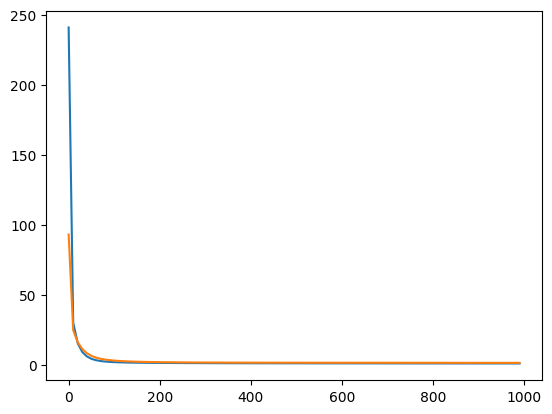

In [496]:
import matplotlib.pyplot as plt

plt.plot(logs["epoch"], logs["weighted_l2_loss"], label="Weighted L2 Loss")
plt.plot(logs["epoch"], logs["sparse_l2_loss"], label="Sparse Weighted L2 Loss")
# plt.xscale('log')
# plt.yscale('log')

In [429]:
sparse_weight.forward_pass_sparse()

tensor([[-1.6706e-05,  1.0502e-02, -2.2886e-06,  ...,  2.4002e-02,
          7.4232e-06,  1.8410e-02],
        [-8.5280e-06,  1.2206e-02, -1.4147e-02,  ..., -3.1661e-02,
          0.0000e+00, -6.1783e-06],
        [ 1.1977e-02, -8.9157e-06, -1.5080e-02,  ...,  1.1777e-05,
         -1.4981e-02, -2.5809e-02],
        ...,
        [ 2.7099e-02, -2.5299e-02, -1.5212e-06,  ..., -2.8204e-02,
         -0.0000e+00, -4.2834e-06],
        [-2.8730e-02,  1.3375e-02,  7.1507e-06,  ...,  1.1525e-02,
          2.5050e-02,  0.0000e+00],
        [ 9.2248e-06, -2.6348e-05,  2.3489e-02,  ..., -7.8378e-03,
         -1.4755e-05, -1.2283e-05]], device='cuda:7', grad_fn=<AddBackward0>)

In [430]:
normalized_weight

tensor([[ 0.0064,  0.0105,  0.0006,  ...,  0.0240,  0.0128,  0.0184],
        [-0.0085,  0.0122, -0.0141,  ..., -0.0317,  0.0005, -0.0041],
        [ 0.0120,  0.0046, -0.0151,  ...,  0.0080, -0.0150, -0.0258],
        ...,
        [ 0.0271, -0.0253,  0.0155,  ..., -0.0282, -0.0045,  0.0022],
        [-0.0287,  0.0134, -0.0012,  ...,  0.0115,  0.0250,  0.0071],
        [-0.0052, -0.0167,  0.0235,  ..., -0.0078, -0.0029, -0.0042]],
       device='cuda:7')

In [495]:
sparse_weight.scaling_1[0]

Parameter containing:
tensor([ 0.0553, -0.0575,  0.0027,  ...,  0.0043, -0.0023, -0.0066],
       device='cuda:7', requires_grad=True)

In [432]:
sparse_weight.weight

Parameter containing:
tensor([[ 8.8597e-05,  1.0502e-02, -6.0451e-05,  ...,  2.4005e-02,
         -9.6207e-05,  1.8435e-02],
        [-6.0408e-05,  1.2203e-02, -1.4145e-02,  ..., -3.1658e-02,
          4.3745e-05,  5.6547e-06],
        [ 1.1992e-02, -1.9924e-05, -1.5091e-02,  ..., -2.0387e-05,
         -1.4999e-02, -2.5814e-02],
        ...,
        [ 2.7104e-02, -2.5323e-02,  6.7946e-05,  ..., -2.8217e-02,
         -2.9070e-05,  1.7848e-05],
        [-2.8726e-02,  1.3383e-02, -1.1995e-05,  ...,  1.1531e-02,
          2.5048e-02, -1.0724e-04],
        [ 8.7363e-05,  9.6627e-05,  2.3491e-02,  ..., -7.8367e-03,
          2.2697e-05, -4.7576e-06]], device='cuda:7', requires_grad=True)

In [425]:
pruned_weight

tensor([[ 0.0000,  0.0105,  0.0000,  ...,  0.0240,  0.0000,  0.0184],
        [-0.0000,  0.0122, -0.0141,  ..., -0.0317,  0.0000, -0.0000],
        [ 0.0120,  0.0000, -0.0151,  ...,  0.0000, -0.0150, -0.0258],
        ...,
        [ 0.0271, -0.0253,  0.0000,  ..., -0.0282, -0.0000,  0.0000],
        [-0.0287,  0.0134, -0.0000,  ...,  0.0115,  0.0250,  0.0000],
        [-0.0000, -0.0000,  0.0235,  ..., -0.0078, -0.0000, -0.0000]],
       device='cuda:7')